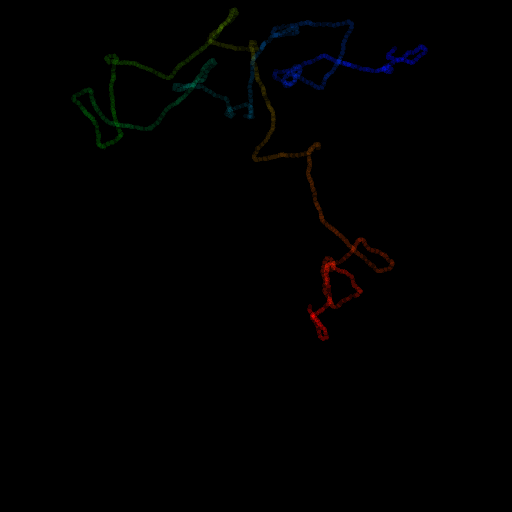

In [6]:
# Jupyter-friendly MP4 -> temporal-coded image exporter
# -----------------------------------------------------
# Edit PARAMETERS below, then run export_temporal_coded_image()
#
# Dependencies:
#   pip install opencv-python pillow numpy
#
# Conventions:
# - Frame indices are 0-based
# - Frame range is inclusive: [START_FRAME, END_FRAME]
# - If END_FRAME exceeds the video length, it is clamped to the final frame
# - Default temporal coding maps early frames to red, middle frames to green,
#   and late frames to blue

import os
import tkinter as tk
from tkinter import filedialog, messagebox

import cv2
import numpy as np
from PIL import Image

try:
    from IPython.display import display
except ImportError:
    display = None


# PARAMETERS (edit here)

START_FRAME = 0          # inclusive
END_FRAME   = 529        # inclusive
TEMPORAL_MODE = "rgb"    # "rgb", "average", or "maximum"
OUTPUT_WIDTH = None      # None keeps original size; otherwise resize to this width
NORMALIZE_OUTPUT = True  # stretch result to the full 0-255 range
PREVIEW_OUTPUT = True    # show saved image in the notebook when possible


# FILE PICKERS

def pick_input_mp4():
    root = tk.Tk()
    root.withdraw()
    root.update()

    messagebox.showinfo("Select input video", "Select an input MP4 file.")
    path = filedialog.askopenfilename(
        title="Select input MP4",
        filetypes=[("MP4 video", "*.mp4"), ("All files", "*.*")]
    )

    root.destroy()
    return path if path else None


def pick_output_image(default_name="temporal_code.png"):
    root = tk.Tk()
    root.withdraw()
    root.update()

    messagebox.showinfo("Save temporal-coded image", "Choose where to save the output image.")
    path = filedialog.asksaveasfilename(
        title="Save temporal-coded image as",
        defaultextension=".png",
        initialfile=default_name,
        filetypes=[
            ("PNG", "*.png"),
            ("JPEG", "*.jpg *.jpeg"),
            ("TIFF", "*.tif *.tiff"),
            ("All files", "*.*"),
        ]
    )

    root.destroy()
    return path if path else None


# VIDEO UTILITIES

def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        raise RuntimeError(f"Could not open video: {video_path}")

    info = {
        "total_frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": float(cap.get(cv2.CAP_PROP_FPS)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    }
    cap.release()

    if info["total_frames"] <= 0:
        raise RuntimeError("Could not determine total frame count.")
    return info


def resize_frame(frame_rgb, output_width):
    if output_width is None:
        return frame_rgb
    if output_width <= 0:
        raise ValueError("OUTPUT_WIDTH must be None or a positive integer.")

    height, width = frame_rgb.shape[:2]
    output_height = int(round(height * (output_width / width)))
    return cv2.resize(frame_rgb, (output_width, output_height), interpolation=cv2.INTER_AREA)


def read_frames_rgb(video_path, start_frame, end_frame, output_width=None):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        raise RuntimeError(f"Could not open video: {video_path}")

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frames = []
    current = start_frame
    while current <= end_frame:
        ok, frame_bgr = cap.read()
        if not ok:
            break
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        frames.append(resize_frame(frame_rgb, output_width))
        current += 1

    cap.release()

    if not frames:
        raise RuntimeError("No frames read.")
    return np.asarray(frames, dtype=np.float32)


def resolve_frame_range(start_frame, end_frame, total_frames):
    if start_frame < 0:
        raise ValueError("START_FRAME must be 0 or greater.")
    if start_frame >= total_frames:
        raise ValueError(
            f"START_FRAME={start_frame} is outside the video "
            f"for total_frames={total_frames}."
        )
    if end_frame < start_frame:
        raise ValueError("END_FRAME must be greater than or equal to START_FRAME.")

    final_frame = total_frames - 1
    return start_frame, min(end_frame, final_frame)


# TEMPORAL CODING UTILITIES

def normalize_to_uint8(image):
    image = np.asarray(image, dtype=np.float32)
    image_min = float(np.min(image))
    image_max = float(np.max(image))

    if image_max <= image_min:
        return np.zeros_like(image, dtype=np.uint8)

    image = (image - image_min) / (image_max - image_min)
    return np.clip(image * 255.0, 0, 255).astype(np.uint8)


def frames_to_grayscale(frames_rgb):
    return (
        0.299 * frames_rgb[..., 0]
        + 0.587 * frames_rgb[..., 1]
        + 0.114 * frames_rgb[..., 2]
    )


def make_temporal_rgb_projection(frames_rgb, normalize_output=True):
    gray = frames_to_grayscale(frames_rgb)
    frame_count = gray.shape[0]

    if frame_count == 1:
        image = np.repeat(gray[0, :, :, np.newaxis], 3, axis=2)
        return normalize_to_uint8(image) if normalize_output else np.clip(image, 0, 255).astype(np.uint8)

    time = np.linspace(0.0, 1.0, frame_count, dtype=np.float32)
    red_weights = np.clip(1.0 - 2.0 * time, 0.0, 1.0)
    green_weights = np.clip(1.0 - np.abs(2.0 * time - 1.0), 0.0, 1.0)
    blue_weights = np.clip(2.0 * time - 1.0, 0.0, 1.0)

    channels = []
    for weights in (red_weights, green_weights, blue_weights):
        weights = weights[:, np.newaxis, np.newaxis]
        weight_sum = float(np.sum(weights))
        if weight_sum == 0.0:
            channels.append(np.mean(gray, axis=0))
        else:
            channels.append(np.sum(gray * weights, axis=0) / weight_sum)

    image = np.stack(channels, axis=2)
    return normalize_to_uint8(image) if normalize_output else np.clip(image, 0, 255).astype(np.uint8)


def make_average_projection(frames_rgb, normalize_output=True):
    image = np.mean(frames_rgb, axis=0)
    return normalize_to_uint8(image) if normalize_output else np.clip(image, 0, 255).astype(np.uint8)


def make_maximum_projection(frames_rgb, normalize_output=True):
    image = np.max(frames_rgb, axis=0)
    return normalize_to_uint8(image) if normalize_output else np.clip(image, 0, 255).astype(np.uint8)


def make_temporal_coded_image(frames_rgb, mode="rgb", normalize_output=True):
    mode = mode.lower().strip()
    if mode == "rgb":
        return make_temporal_rgb_projection(frames_rgb, normalize_output)
    if mode == "average":
        return make_average_projection(frames_rgb, normalize_output)
    if mode == "maximum":
        return make_maximum_projection(frames_rgb, normalize_output)

    raise ValueError('TEMPORAL_MODE must be "rgb", "average", or "maximum".')


# IMAGE OUTPUT UTILITIES

def save_image(image_rgb, output_path):
    extension = os.path.splitext(output_path)[1].lower()
    if extension not in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}:
        raise ValueError("Output image must end with .png, .jpg, .jpeg, .tif, or .tiff.")

    Image.fromarray(image_rgb).save(output_path)


def preview_image(image_rgb):
    if display is not None:
        display(Image.fromarray(image_rgb))


# MAIN WORKFLOW

def export_temporal_coded_image():
    mp4_path = pick_input_mp4()
    if not mp4_path:
        return

    base = os.path.splitext(os.path.basename(mp4_path))[0]
    output_path = pick_output_image(default_name=f"{base}_temporal_code.png")
    if not output_path:
        return

    video_info = get_video_info(mp4_path)
    total_frames = video_info["total_frames"]

    start_frame, end_frame = resolve_frame_range(START_FRAME, END_FRAME, total_frames)

    frames_rgb = read_frames_rgb(mp4_path, start_frame, end_frame, OUTPUT_WIDTH)
    temporal_image = make_temporal_coded_image(
        frames_rgb,
        mode=TEMPORAL_MODE,
        normalize_output=NORMALIZE_OUTPUT,
    )
    save_image(temporal_image, output_path)

    if PREVIEW_OUTPUT:
        preview_image(temporal_image)

    root = tk.Tk()
    root.withdraw()
    root.update()
    messagebox.showinfo("Done", f"Saved temporal-coded image:\n{output_path}")
    root.destroy()



# Run from notebook cell:

export_temporal_coded_image()
